## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [17]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV





In [5]:
# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

df = pd.read_csv("housing_Data.csv")

# Display first five rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Display first five rows
print(df.head().to_string())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement hotwaterheating airconditioning  parking prefarea furnishingstatus
0  13300000  7420         4          2        3      yes        no       no              no             yes        2      yes        furnished
1  12250000  8960         4          4        4      yes        no       no              no             yes        3       no        furnished
2  12250000  9960         3          2        2      yes        no      yes              no              no        2      yes   semi-furnished
3  12215000  7500         4          2        2      yes        no      yes              no             yes        3      yes        furnished
4  11410000  7420         4          1        2      yes       yes      yes              no             yes        2       no        furnished


In [7]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.
print("To inspect data types")
print( df.info())

print("\n","statistical properties")
print(df.describe().round(2).to_string())



To inspect data types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

 statistical properties
             price      area  bedrooms  bathrooms  stories  parking
count       545.00    545.00    54

In [14]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

print("To check for null values",df.isnull().sum())

df = pd.get_dummies(df, drop_first=True)
print("Converted the categorical variables:",df.head().to_string())


To check for null values price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
parking                            0
mainroad_yes                       0
guestroom_yes                      0
basement_yes                       0
hotwaterheating_yes                0
airconditioning_yes                0
prefarea_yes                       0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64
Converted the categorical variables:       price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished
0  13300000  7420         4          2        3        2          True          False         False                False                 True          True                            False

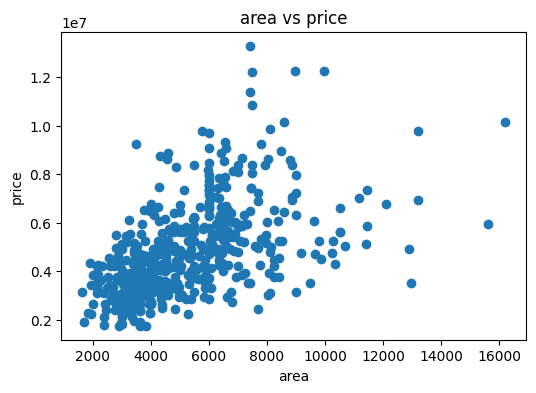

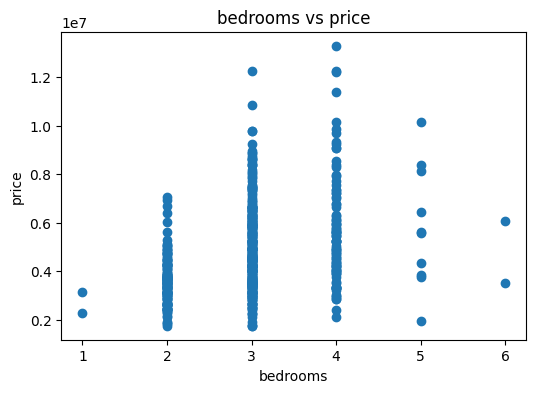

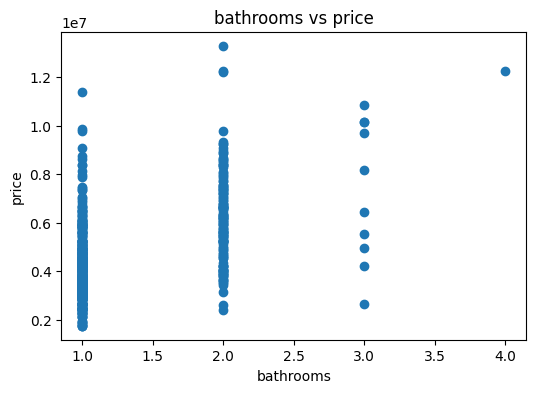

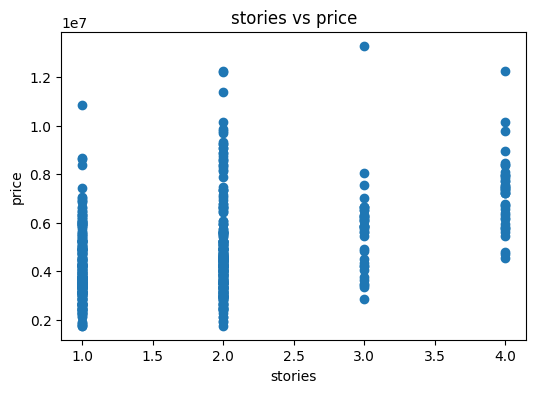

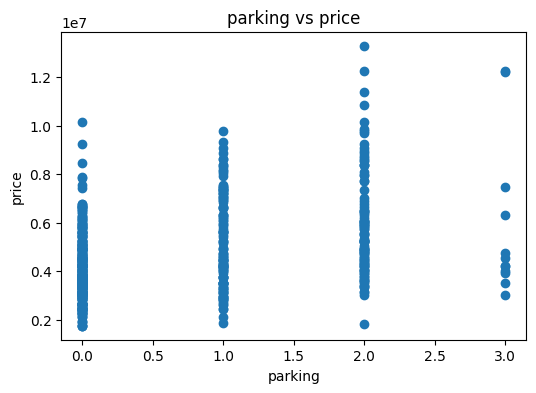

In [16]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').

# List of numerical features
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define a function to create scatter plots
def scatter_plots(data, feature_list, target):
    for feature in feature_list:
        plt.figure(figsize=(6,4))
        plt.scatter(data[feature], data[target])
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
        plt.show()


# TODO: Use the function to visualize the relationships between multiple features and the target variable.
scatter_plots(df, features, 'price')



**Observation:** The scatter plots show the relationship between the selected numerical features and house price. Features such as area, bathrooms, and parking have a stronger positive relationship with the target variable (price). The function makes it easy to generate multiple scatter plots without writing the same code repeatedly.

In [15]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:
X = df.drop('price', axis=1)   # All columns except 'price'
y = df['price']                # Target variable

# Split the dataset into training and testing sets (80% training, 20% testing)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Display the shapes of the datasets
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)


Training Features: (436, 13)
Testing Features: (109, 13)
Training Target: (436,)
Testing Target: (109,)


**Observation:** The dataset was split into 80% training data and 20% testing data. The training set has 436 records, and the testing set has 109 records. Both datasets contain 13 features. The training data is used to train the model, and the testing data is used to check how accurately the model predicts house prices.

In [19]:
# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Hint: Use either `DecisionTreeRegressor` or `RandomForestRegressor` from `sklearn.tree` or `sklearn.ensemble`.

# Define your regression model here:

randfor_model = RandomForestRegressor( n_estimators=100,random_state=42)

**Observation**: A Random Forest Regressor was selected because it combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [20]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# # Train the model

randfor_model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

**Observation:**
The model was trained using the training dataset. During training, the Random Forest algorithm learned the relationship between the house features and the house price.

In [23]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.
# Predict on the test set
y_pred = randfor_model.predict(X_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)


RMSE: 1400565.9728553821
R-squared: 0.611918531405699


**Observation:** The Random Forest model achieved an RMSE of 1,400,565.97 and an R² score of 0.6119. This means the model explains about 61.19% of the variation in house prices. The RMSE indicates an average prediction error of approximately 1.4 million, suggesting that the model performs reasonably well but could be improved with additional feature engineering or parameter tuning.

In [26]:
# Perform parameter tuning on the model if needed to improve the performance of your model.
# Add your parameter tuning code here:
# Tune the Random Forest model
# Predict on the test set and calculate the evaluation metrics:

randfor_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

# Train the model
randfor_model.fit(X_train, y_train)

# Predict on the test set
y_pred = randfor_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)

RMSE: 1391845.5170503582
R-squared: 0.6167361716402375


**Observation:** After manually tuning the Random Forest model, the RMSE decreased from 1,400,565.97 to 1,391,845.52, while the R² score increased from 0.6119 to 0.6167. This indicates that parameter tuning slightly improved the model's performance. The tuned model predicts house prices more accurately than the initial model.

In [30]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.

# Create a new house with hypothetical values
new_house_data = pd.DataFrame({
    'area': [7000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad_yes': [1],
    'guestroom_yes': [0],
    'basement_yes': [1],
    'hotwaterheating_yes': [0],
    'airconditioning_yes': [1],
    'parking': [2],
    'prefarea_yes': [1],
    'furnishingstatus_semi-furnished': [1],
    'furnishingstatus_unfurnished': [0]
})

# Ensure the new_house_data has the same columns and order as the training data
# and fill any missing columns with 0
new_house_data = new_house_data.reindex(columns=X_train.columns, fill_value=0)

# Predict the house price
predicted_House_price = randfor_model.predict(new_house_data)

print("Predicted House Price:", predicted_House_price[0])

Predicted House Price: 8405201.0


**Observation:** The trained and tuned Random Forest model predicted a house price of 8,405,201 for the new house based on the given input features. This prediction represents the estimated selling price according to the patterns learned from the training data.

Git hub Link: https://github.com/7500nidhi/Artificial_Intelligence_Course.git